# Thesis 08: Across-Experiment Comparison

Collect the thesis result artifacts into one analysis surface so differences between dataset generation, optimizer, loss balancing, collocation, multistage, data augmentation, and final experiments can be compared consistently. This notebook starts from the exported `results/tables/*` tables created by the preceding analysis notebooks.

## Imports

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src").is_dir():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            return candidate
    raise FileNotFoundError(f"Could not find repository root from {cwd}")


REPO = find_repo_root()

from results.notebook_utils import table_dir, write_table  # noqa: E402
from src.visualization.thesis_style import (  # noqa: E402
    DTU_COLORS,
    NEUTRAL_COLORS,
    THESIS_COLOR_CYCLE,
    apply_thesis_axis_style,
    log_minor_grid,
    save_figure,
    set_thesis_style,
)

set_thesis_style()

DATA = REPO / "results" / "data"
TABLES = REPO / "results" / "tables"
EXPORT = DATA / "thesis_08_across_experiments"
# Scratch export directory is intentionally not created for repository submission.
TABLE_EXPORT = table_dir("across_experiments")

## Load Exported Thesis Tables

The earlier notebooks do the experiment-specific parsing and posthoc overlay. Here we keep those semantics and only harmonize common fields across experiments.

In [2]:
SUMMARY_SPECS = [
    {
        "experiment_id": "01_dataset_generation",
        "experiment_label": "Dataset generation",
        "path": TABLES / "01_dataset_generation" / "main_numeric.csv",
        "label_cols": ["budget", "method"],
        "metric_prefix": "direct",
    },
    {
        "experiment_id": "02_optimizer_comparison",
        "experiment_label": "Optimizer comparison",
        "path": TABLES / "02_optimizer_comparison" / "main_numeric.csv",
        "label_cols": ["analysis_key"],
        "metric_prefix": "best",
    },
    {
        "experiment_id": "03_loss_balancing",
        "experiment_label": "Loss balancing",
        "path": TABLES / "03_loss_balancing" / "main_numeric.csv",
        "label_cols": ["strategy"],
        "metric_prefix": "best",
    },
    {
        "experiment_id": "04_collocation_comparison",
        "experiment_label": "Collocation sampling",
        "path": TABLES / "04_collocation_comparison" / "main_numeric.csv",
        "label_cols": ["density_label", "strategy"],
        "metric_prefix": "best",
    },
    {
        "experiment_id": "05_multistage",
        "experiment_label": "Multistage training",
        "path": TABLES / "05_multistage" / "main_numeric.csv",
        "label_cols": ["strategy"],
        "metric_prefix": "best",
    },
    {
        "experiment_id": "06_data_augmentation",
        "experiment_label": "Data augmentation",
        "path": TABLES / "06_data_augmentation" / "main_numeric.csv",
        "label_cols": ["supervised_strategy", "collocation_strategy"],
        "metric_prefix": "best",
    },
    {
        "experiment_id": "07_final_experiment",
        "experiment_label": "Final experiment",
        "path": TABLES / "07_final_experiment" / "full_external_numeric.csv",
        "label_cols": ["model_label", "strategy_label"],
        "metric_prefix": "best",
        "filter_col": "model_flag",
        "filter_value": "SM4",
    },
]

RUN_SPECS = [
    ("02_optimizer_comparison", "Optimizer comparison", DATA / "thesis_02_optimizer_comparison" / "runs.csv"),
    ("03_loss_balancing", "Loss balancing", DATA / "thesis_03_loss_balancing" / "runs.csv"),
    ("04_collocation_comparison", "Collocation sampling", DATA / "thesis_04_collocation_comparison" / "runs.csv"),
    ("05_multistage", "Multistage training", DATA / "thesis_05_multistage" / "runs.csv"),
    ("06_data_augmentation", "Data augmentation", DATA / "thesis_06_data_augmentation" / "runs.csv"),
    ("07_final_experiment", "Final experiment", DATA / "thesis_07_final_experiment" / "analysis_runs.csv"),
]


def read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def make_label(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    existing = [col for col in columns if col in frame.columns]
    if not existing:
        return pd.Series(np.arange(len(frame)).astype(str), index=frame.index)
    return frame[existing].astype(str).agg(" / ".join, axis=1)


summary_frames = []
inventory_rows = []
for spec in SUMMARY_SPECS:
    frame = read_csv(spec["path"])
    inventory_rows.append({
        "artifact_type": "summary",
        "experiment_id": spec["experiment_id"],
        "experiment_label": spec["experiment_label"],
        "path": str(spec["path"].relative_to(REPO)),
        "exists": spec["path"].exists(),
        "rows": len(frame),
        "columns": frame.shape[1],
        "filter": "" if "filter_col" not in spec else f"{spec['filter_col']} == {spec['filter_value']}",
    })
    if frame.empty:
        continue
    frame = frame.copy()
    if spec.get("filter_col") in frame.columns:
        frame = frame[frame[spec["filter_col"]].astype(str) == str(spec["filter_value"])].copy()
    frame.insert(0, "experiment_id", spec["experiment_id"])
    frame.insert(1, "experiment_label", spec["experiment_label"])
    frame.insert(2, "configuration", make_label(frame, spec["label_cols"]))
    frame.insert(3, "metric_prefix", spec["metric_prefix"])
    summary_frames.append(frame)

run_frames = []
for experiment_id, experiment_label, path in RUN_SPECS:
    frame = read_csv(path)
    inventory_rows.append({
        "artifact_type": "run_level",
        "experiment_id": experiment_id,
        "experiment_label": experiment_label,
        "path": str(path.relative_to(REPO)),
        "exists": path.exists(),
        "rows": len(frame),
        "columns": frame.shape[1],
    })
    if frame.empty:
        continue
    frame = frame.copy()
    if experiment_id == "07_final_experiment" and "model_flag" in frame.columns:
        frame = frame[frame["model_flag"].astype(str) == "SM4"].copy()
    frame.insert(0, "experiment_id", experiment_id)
    frame.insert(1, "experiment_label", experiment_label)
    run_frames.append(frame)

summary_raw = pd.concat(summary_frames, ignore_index=True, sort=False) if summary_frames else pd.DataFrame()
runs_raw = pd.concat(run_frames, ignore_index=True, sort=False) if run_frames else pd.DataFrame()
artifact_inventory = pd.DataFrame(inventory_rows)

# Scratch export disabled for repository submission; keep derived data in memory.
# artifact_inventory.to_csv(EXPORT / "artifact_inventory.csv", index=False)
display(artifact_inventory)

,artifact_type,experiment_id,experiment_label,path,exists,rows,columns,filter
0,summary,01_dataset_generation,Dataset generation,results/tables/01_dataset_generation/main_nume...,True,12,79,
1,summary,02_optimizer_comparison,Optimizer comparison,results/tables/02_optimizer_comparison/main_nu...,True,7,81,
2,summary,03_loss_balancing,Loss balancing,results/tables/03_loss_balancing/main_numeric.csv,True,8,81,
3,summary,04_collocation_comparison,Collocation sampling,results/tables/04_collocation_comparison/main_...,True,9,82,
4,summary,05_multistage,Multistage training,results/tables/05_multistage/main_numeric.csv,True,3,85,
5,summary,06_data_augmentation,Data augmentation,results/tables/06_data_augmentation/main_numer...,True,8,110,
6,summary,07_final_experiment,Final experiment,results/tables/07_final_experiment/full_extern...,False,0,0,model_flag == SM4
7,run_level,02_optimizer_comparison,Optimizer comparison,results/data/thesis_02_optimizer_comparison/ru...,False,0,0,NaN
8,run_level,03_loss_balancing,Loss balancing,results/data/thesis_03_loss_balancing/runs.csv,False,0,0,NaN
9,run_level,04_collocation_comparison,Collocation sampling,results/data/thesis_04_collocation_comparison/...,False,0,0,NaN


## Harmonize Common Metrics

In [3]:
COMMON_METRICS = {
    "id_mse": ["id_mse_mean", "best_id_eval_mse_mean"],
    "id_mse_sem": ["id_mse_sem", "best_id_eval_mse_sem"],
    "ood_mse": ["ood_mse_mean", "best_ood_eval_mse_mean"],
    "ood_mse_sem": ["ood_mse_sem", "best_ood_eval_mse_sem"],
    "id_mae": ["id_mae_mean", "best_id_eval_mae_mean"],
    "ood_mae": ["ood_mae_mean", "best_ood_eval_mae_mean"],
    "id_max_abs_error": ["id_max_abs_error_mean", "best_id_eval_max_abs_error_mean"],
    "ood_max_abs_error": ["ood_max_abs_error_mean", "best_ood_eval_max_abs_error_mean"],
    "id_trajectory_mse_p95": ["id_trajectory_mse_p95_mean", "best_id_eval_trajectory_mse_p95_mean"],
    "ood_trajectory_mse_p95": ["ood_trajectory_mse_p95_mean", "best_ood_eval_trajectory_mse_p95_mean"],
    "id_trajectory_mse_max": ["id_trajectory_mse_max_mean", "best_id_eval_trajectory_mse_max_mean"],
    "ood_trajectory_mse_max": ["ood_trajectory_mse_max_mean", "best_ood_eval_trajectory_mse_max_mean"],
    "training_seconds": ["training_seconds_mean"],
    "total_seconds": ["total_seconds_mean"],
    "n_runs": ["n_runs"],
}


def first_available(row: pd.Series, candidates: list[str]) -> float:
    for col in candidates:
        if col in row.index and pd.notna(row[col]):
            return row[col]
    return np.nan


records = []
for _, row in summary_raw.iterrows():
    out = {
        "experiment_id": row["experiment_id"],
        "experiment_label": row["experiment_label"],
        "configuration": row["configuration"],
        "metric_prefix": row["metric_prefix"],
    }
    for metric, candidates in COMMON_METRICS.items():
        out[metric] = first_available(row, candidates)
    if pd.isna(out["training_seconds"]):
        hours = first_available(row, ["training_hours_mean"])
        out["training_seconds"] = np.nan if pd.isna(hours) else float(hours) * 3600.0
    out["ood_id_mse_gap"] = out["ood_mse"] - out["id_mse"]
    out["ood_id_mse_ratio"] = out["ood_mse"] / out["id_mse"] if pd.notna(out["id_mse"]) and out["id_mse"] != 0 else np.nan
    records.append(out)

summary_metrics = pd.DataFrame(records)
# Scratch export disabled for repository submission; keep derived data in memory.
# summary_metrics.to_csv(EXPORT / "summary_metrics_harmonized.csv", index=False)

metric_availability = (
    summary_metrics.groupby("experiment_label", observed=True)
    .agg(**{metric: (metric, lambda s: int(s.notna().sum())) for metric in COMMON_METRICS})
    .reset_index()
)
# Scratch export disabled for repository submission; keep derived data in memory.
# metric_availability.to_csv(EXPORT / "metric_availability.csv", index=False)

display(summary_metrics.head(12))
display(metric_availability)

,experiment_id,experiment_label,configuration,metric_prefix,id_mse,id_mse_sem,ood_mse,ood_mse_sem,id_mae,ood_mae,...,ood_max_abs_error,id_trajectory_mse_p95,ood_trajectory_mse_p95,id_trajectory_mse_max,ood_trajectory_mse_max,training_seconds,total_seconds,n_runs,ood_id_mse_gap,ood_id_mse_ratio
0,01_dataset_generation,Dataset generation,b256 / lhs_static,direct,6.530144e-06,1.072672e-06,0.023589,0.001761,0.001392,0.050457,...,1.691263,0.000021,0.143289,0.000475,0.661001,NaN,NaN,NaN,0.023582,3612.286717
1,01_dataset_generation,Dataset generation,b256 / qbc_deep_ensemble,direct,5.349998e-06,6.156861e-07,0.020166,0.001305,0.001471,0.045113,...,1.656381,0.000014,0.129856,0.000122,0.592120,NaN,NaN,NaN,0.020161,3769.378917
2,01_dataset_generation,Dataset generation,b256 / marker_directed,direct,6.132513e-06,7.447493e-07,0.024831,0.000517,0.001445,0.051888,...,1.765604,0.000017,0.156658,0.000422,0.710700,NaN,NaN,NaN,0.024824,4049.012041
3,01_dataset_generation,Dataset generation,b512 / lhs_static,direct,2.530087e-06,1.915095e-07,0.021222,0.001203,0.000907,0.045802,...,1.712648,0.000007,0.128720,0.000269,0.689492,NaN,NaN,NaN,0.021220,8388.029991
4,01_dataset_generation,Dataset generation,b512 / qbc_deep_ensemble,direct,2.032481e-06,2.690011e-07,0.019217,0.000359,0.000904,0.042876,...,1.574400,0.000005,0.120682,0.000046,0.585615,NaN,NaN,NaN,0.019215,9454.855939
5,01_dataset_generation,Dataset generation,b512 / marker_directed,direct,2.315276e-06,8.116789e-08,0.022778,0.000425,0.000938,0.048313,...,1.729968,0.000006,0.145116,0.000090,0.655556,NaN,NaN,NaN,0.022776,9838.126579
6,01_dataset_generation,Dataset generation,b1024 / lhs_static,direct,1.273212e-06,5.603558e-08,0.019586,0.000028,0.000660,0.042988,...,1.640846,0.000003,0.120178,0.000111,0.643090,NaN,NaN,NaN,0.019585,15383.386672
7,01_dataset_generation,Dataset generation,b1024 / qbc_deep_ensemble,direct,1.089996e-06,5.063161e-08,0.020657,0.001474,0.000671,0.043180,...,1.690409,0.000002,0.133821,0.000008,0.642971,NaN,NaN,NaN,0.020656,18951.274299
8,01_dataset_generation,Dataset generation,b1024 / marker_directed,direct,1.219878e-06,3.647143e-08,0.022607,0.000272,0.000676,0.045643,...,1.734472,0.000003,0.141247,0.000023,0.688918,NaN,NaN,NaN,0.022606,18531.972775
9,01_dataset_generation,Dataset generation,b4096 / lhs_static,direct,6.213995e-07,2.366025e-08,0.018102,0.000981,0.000468,0.039839,...,1.573121,0.000002,0.112773,0.000019,0.595688,NaN,NaN,NaN,0.018101,29130.668752


,experiment_label,id_mse,id_mse_sem,ood_mse,ood_mse_sem,id_mae,ood_mae,id_max_abs_error,ood_max_abs_error,id_trajectory_mse_p95,ood_trajectory_mse_p95,id_trajectory_mse_max,ood_trajectory_mse_max,training_seconds,total_seconds,n_runs
0,Collocation sampling,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
1,Data augmentation,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
2,Dataset generation,12,12,12,12,12,12,12,12,12,12,12,12,0,0,0
3,Loss balancing,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
4,Multistage training,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
5,Optimizer comparison,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7


## Best Configuration Per Experiment

This first pass ranks configurations by ID MSE and OOD MSE separately. The comparison is diagnostic: experiments do not all use identical model scopes or design spaces.

In [4]:
def best_rows(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    rows = []
    for experiment_label, sub in frame.dropna(subset=[metric]).groupby("experiment_label", observed=True):
        best = sub.sort_values(metric, ascending=True).iloc[0].copy()
        best["ranking_metric"] = metric
        rows.append(best)
    return pd.DataFrame(rows)


best_by_experiment = pd.concat(
    [best_rows(summary_metrics, "id_mse"), best_rows(summary_metrics, "ood_mse")],
    ignore_index=True,
    sort=False,
)
best_by_experiment = best_by_experiment[
    [
        "ranking_metric", "experiment_id", "experiment_label", "configuration",
        "id_mse", "ood_mse", "ood_id_mse_gap", "ood_id_mse_ratio",
        "id_trajectory_mse_p95", "ood_trajectory_mse_p95", "training_seconds", "n_runs",
    ]
]
# Scratch export disabled for repository submission; keep derived data in memory.
# best_by_experiment.to_csv(EXPORT / "best_by_experiment.csv", index=False)
display(best_by_experiment)

,ranking_metric,experiment_id,experiment_label,configuration,id_mse,ood_mse,ood_id_mse_gap,ood_id_mse_ratio,id_trajectory_mse_p95,ood_trajectory_mse_p95,training_seconds,n_runs
0,id_mse,04_collocation_comparison,Collocation sampling,p64k / rad,2.532555e-06,0.030393,0.030390,12000.733460,7.663814e-06,0.196932,6233.495912,3.0
1,id_mse,06_data_augmentation,Data augmentation,random_growth / rar_d_growth,1.772389e-06,0.025132,0.025130,14179.706705,5.384383e-06,0.164850,6927.852321,3.0
2,id_mse,01_dataset_generation,Dataset generation,b4096 / qbc_deep_ensemble,6.121514e-07,0.020361,0.020361,33262.170791,1.204514e-06,0.127397,NaN,NaN
3,id_mse,03_loss_balancing,Loss balancing,data_warmup_static,3.025163e-06,0.027534,0.027531,9101.604730,8.872485e-06,0.181926,14158.938994,3.0
4,id_mse,05_multistage,Multistage training,multistage_adam_correction,3.199719e-06,0.025886,0.025882,8089.954324,8.890289e-06,0.162633,9738.585462,3.0
5,id_mse,02_optimizer_comparison,Optimizer comparison,adam_ssbroyden,2.351319e-08,0.000706,0.000706,30012.763414,8.003253e-08,0.000943,1773.455165,3.0
6,ood_mse,04_collocation_comparison,Collocation sampling,p4k / uniform_lhs,2.975161e-06,0.027119,0.027116,9115.011327,8.246625e-06,0.171905,6884.142466,3.0
7,ood_mse,06_data_augmentation,Data augmentation,random_growth / rar_d_growth,1.772389e-06,0.025132,0.025130,14179.706705,5.384383e-06,0.164850,6927.852321,3.0
8,ood_mse,01_dataset_generation,Dataset generation,b4096 / lhs_static,6.213995e-07,0.018102,0.018101,29130.668752,1.567141e-06,0.112773,NaN,NaN
9,ood_mse,03_loss_balancing,Loss balancing,dn,1.004031e-05,0.015243,0.015233,1518.198489,2.897516e-05,0.083485,15807.323331,3.0


## Run-Level Inventory

In [5]:
RUN_METRICS = [
    "best_id_eval_mse", "best_ood_eval_mse", "best_id_eval_mae", "best_ood_eval_mae",
    "final_test_mse", "training_seconds", "total_seconds", "status", "seed_label",
]

run_cols = ["experiment_id", "experiment_label"] + [col for col in RUN_METRICS if col in runs_raw.columns]
run_metrics = runs_raw[run_cols].copy() if len(run_cols) > 2 else pd.DataFrame()
if not run_metrics.empty:
    run_metrics["ood_id_mse_gap"] = run_metrics.get("best_ood_eval_mse") - run_metrics.get("best_id_eval_mse")
    # Scratch export disabled for repository submission; keep derived data in memory.
    # run_metrics.to_csv(EXPORT / "run_metrics_harmonized.csv", index=False)

run_overview = (
    run_metrics.groupby("experiment_label", observed=True)
    .agg(
        rows=("experiment_id", "size"),
        completed=("status", lambda s: int((s.astype(str) == "completed").sum())) if "status" in run_metrics else ("experiment_id", "size"),
        id_mse_available=("best_id_eval_mse", lambda s: int(s.notna().sum())) if "best_id_eval_mse" in run_metrics else ("experiment_id", "size"),
        ood_mse_available=("best_ood_eval_mse", lambda s: int(s.notna().sum())) if "best_ood_eval_mse" in run_metrics else ("experiment_id", "size"),
    )
    .reset_index()
) if not run_metrics.empty else pd.DataFrame()
# Scratch export disabled for repository submission; keep derived data in memory.
# run_overview.to_csv(EXPORT / "run_overview.csv", index=False)
display(run_overview)

""


## Starter Cross-Experiment Views

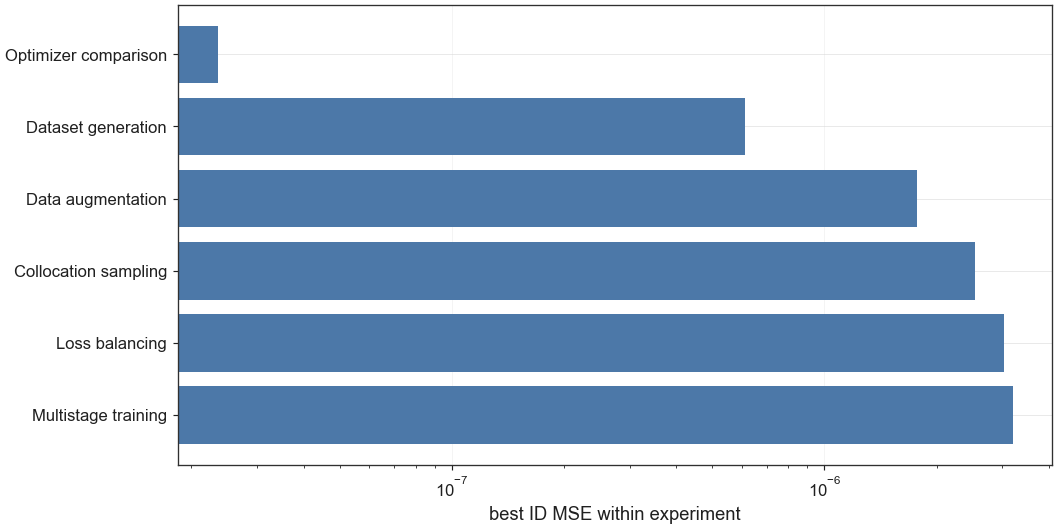

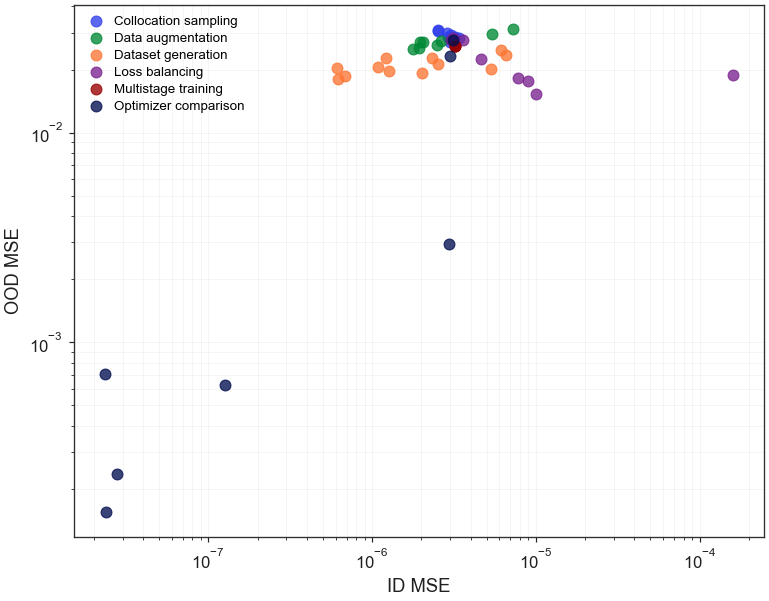

In [6]:
plot_data = best_by_experiment[best_by_experiment["ranking_metric"] == "id_mse"].copy()
plot_data = plot_data.sort_values("id_mse", ascending=False)

fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.barh(plot_data["experiment_label"], plot_data["id_mse"], color="#4C78A8")
ax.set_xscale("log")
ax.set_xlabel("best ID MSE within experiment")
ax.set_ylabel("")
ax.grid(True, axis="x", alpha=0.35)
fig.tight_layout()
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(EXPORT / "best_id_mse_by_experiment.png", dpi=300, bbox_inches="tight")
plt.show()

tradeoff = summary_metrics.dropna(subset=["id_mse", "ood_mse"]).copy()
fig, ax = plt.subplots(figsize=(6.6, 5.2))
for experiment_label, sub in tradeoff.groupby("experiment_label", observed=True):
    ax.scatter(sub["id_mse"], sub["ood_mse"], label=experiment_label, alpha=0.78, s=42)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("ID MSE")
ax.set_ylabel("OOD MSE")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(EXPORT / "id_vs_ood_mse_all_experiments.png", dpi=300, bbox_inches="tight")
plt.show()

## Best-Result Metric Comparisons

For each main metric, select the best SM4 configuration within each experiment by the corresponding ID metric, then compare its ID and OOD performance. The final experiment is restricted to `model_flag == "SM4"` so it is comparable with the SM4-focused earlier experiments.


,metric,metric_label,experiment_id,experiment_label,configuration,id_value,ood_value,ood_id_gap,ood_id_ratio,training_seconds,n_runs
0,mse,MSE,04_collocation_comparison,Collocation sampling,p64k / rad,2.532555e-06,0.030393,0.030390,12000.733460,6233.495912,3.0
1,mse,MSE,06_data_augmentation,Data augmentation,random_growth / rar_d_growth,1.772389e-06,0.025132,0.025130,14179.706705,6927.852321,3.0
2,mse,MSE,01_dataset_generation,Dataset generation,b4096 / qbc_deep_ensemble,6.121514e-07,0.020361,0.020361,33262.170791,NaN,NaN
3,mse,MSE,03_loss_balancing,Loss balancing,data_warmup_static,3.025163e-06,0.027534,0.027531,9101.604730,14158.938994,3.0
4,mse,MSE,05_multistage,Multistage training,multistage_adam_correction,3.199719e-06,0.025886,0.025882,8089.954324,9738.585462,3.0
5,mse,MSE,02_optimizer_comparison,Optimizer comparison,adam_ssbroyden,2.351319e-08,0.000706,0.000706,30012.763414,1773.455165,3.0
6,mae,MAE,04_collocation_comparison,Collocation sampling,p64k / rad,9.485314e-04,0.054737,0.053788,57.707040,6233.495912,3.0
7,mae,MAE,06_data_augmentation,Data augmentation,random_growth / rar_d_growth,8.106668e-04,0.048972,0.048162,60.409916,6927.852321,3.0
8,mae,MAE,01_dataset_generation,Dataset generation,b4096 / lhs_static,4.684327e-04,0.039839,0.039370,85.046831,NaN,NaN
9,mae,MAE,03_loss_balancing,Loss balancing,data_warmup_static,1.051968e-03,0.051234,0.050182,48.702658,14158.938994,3.0


,metric,experiment,best configuration,ID value,OOD value,OOD / ID,training time [h],runs
0,MSE,Collocation sampling,p64k / rad,2.53e-06,3.04e-02,12000.7x,1.73,3
1,MSE,Data augmentation,random_growth / rar_d_growth,1.77e-06,2.51e-02,14179.7x,1.92,3
2,MSE,Dataset generation,b4096 / qbc_deep_ensemble,6.12e-07,2.04e-02,33262.2x,not available,not available
3,MSE,Loss balancing,data_warmup_static,3.03e-06,2.75e-02,9101.6x,3.93,3
4,MSE,Multistage training,multistage_adam_correction,3.20e-06,2.59e-02,8090.0x,2.71,3
5,MSE,Optimizer comparison,adam_ssbroyden,2.35e-08,7.06e-04,30012.8x,0.49,3
6,MAE,Collocation sampling,p64k / rad,9.49e-04,5.47e-02,57.7x,1.73,3
7,MAE,Data augmentation,random_growth / rar_d_growth,8.11e-04,4.90e-02,60.4x,1.92,3
8,MAE,Dataset generation,b4096 / lhs_static,4.68e-04,3.98e-02,85.0x,not available,not available
9,MAE,Loss balancing,data_warmup_static,1.05e-03,5.12e-02,48.7x,3.93,3


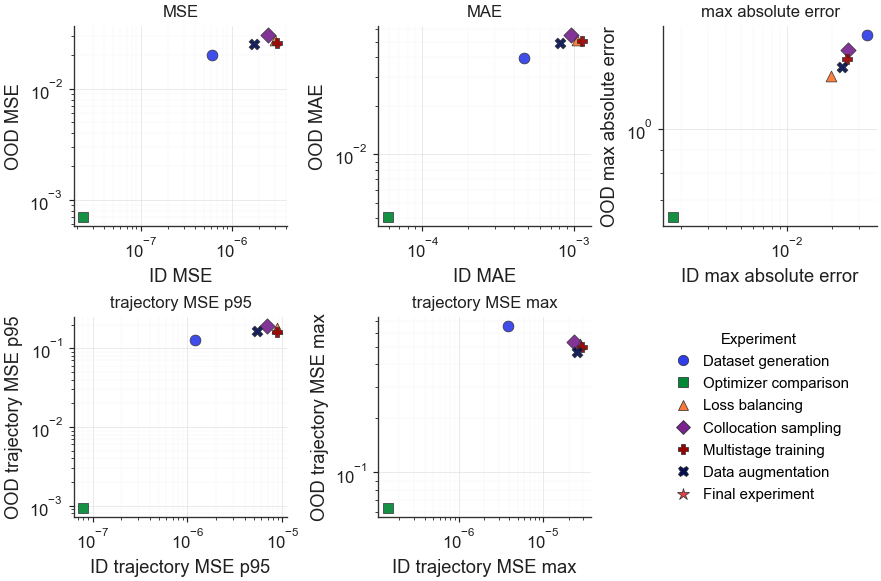

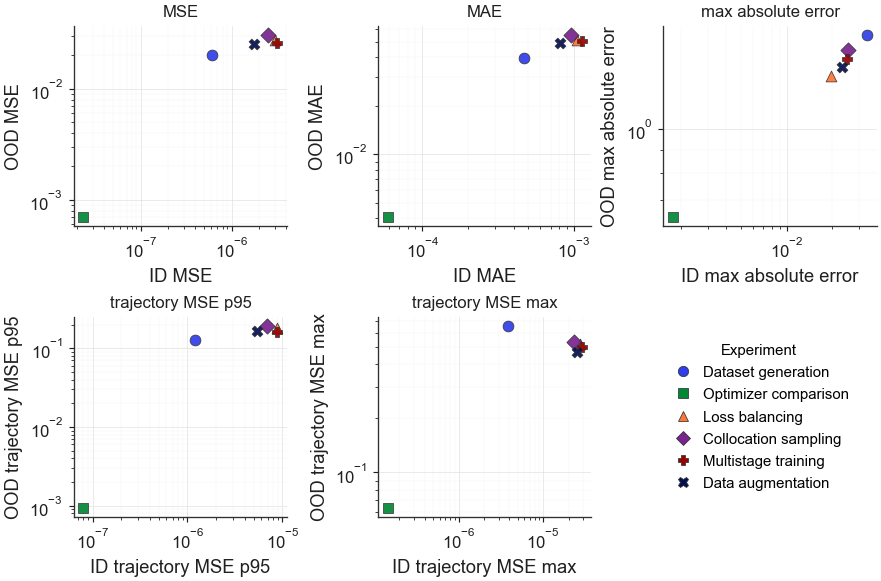

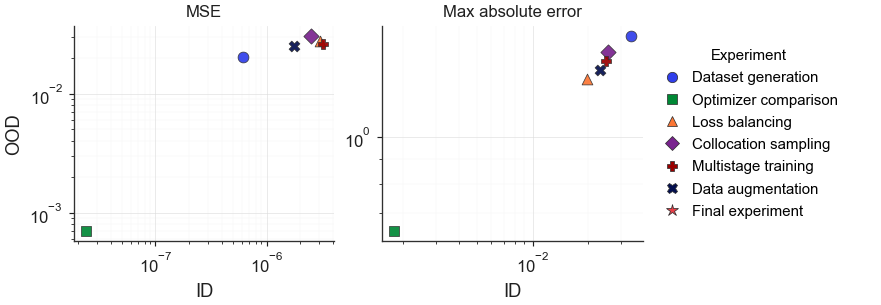

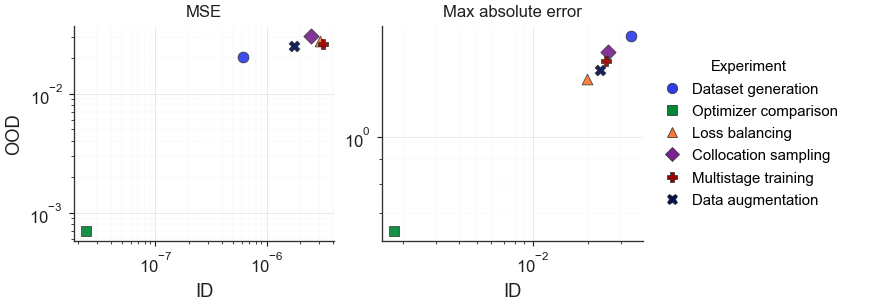

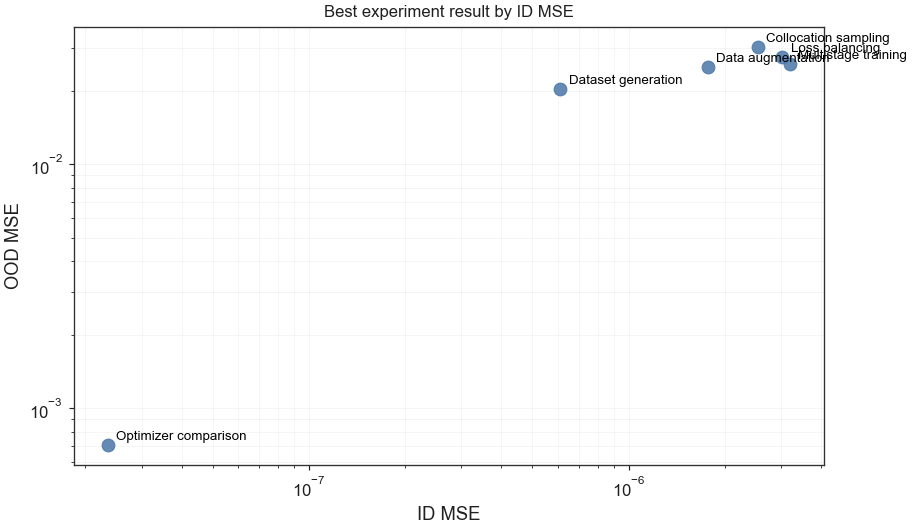

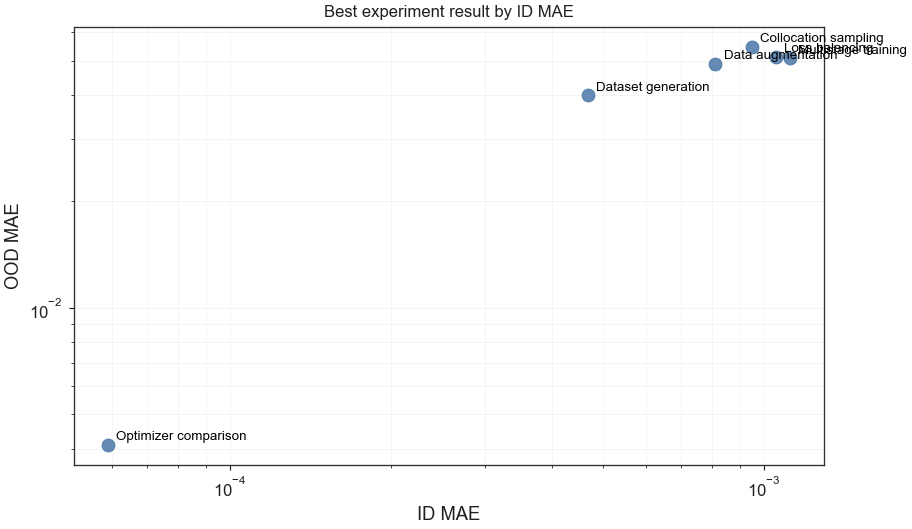

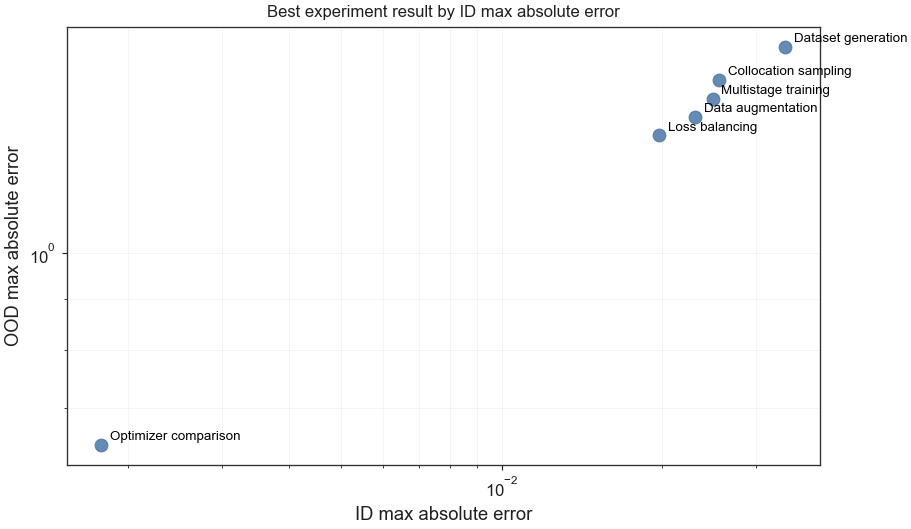

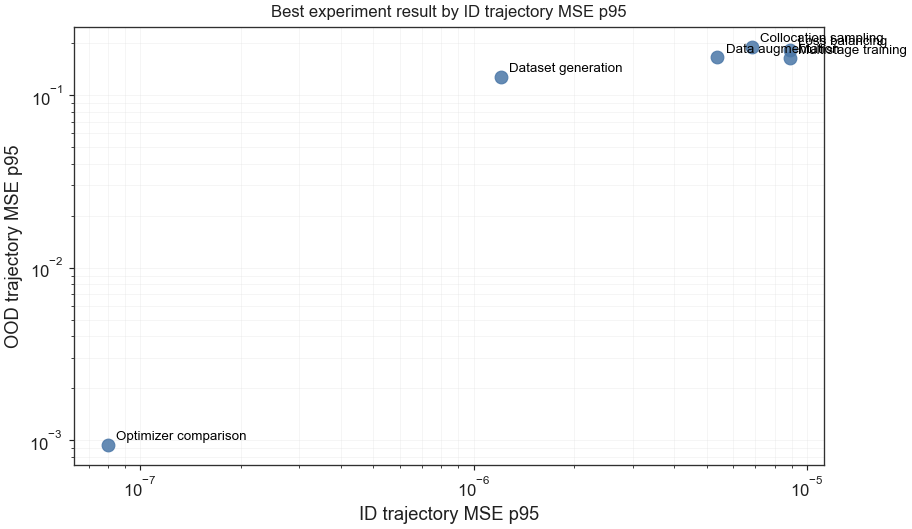

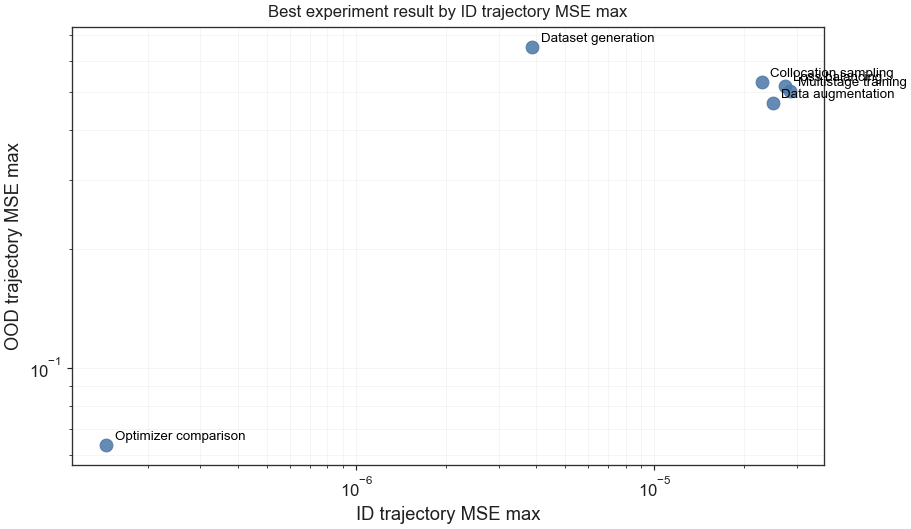

In [7]:
MAIN_METRIC_PAIRS = [
    ("mse", "id_mse", "ood_mse", "MSE"),
    ("mae", "id_mae", "ood_mae", "MAE"),
    ("max_abs_error", "id_max_abs_error", "ood_max_abs_error", "max absolute error"),
    ("trajectory_mse_p95", "id_trajectory_mse_p95", "ood_trajectory_mse_p95", "trajectory MSE p95"),
    ("trajectory_mse_max", "id_trajectory_mse_max", "ood_trajectory_mse_max", "trajectory MSE max"),
]

best_metric_rows = []
for metric_key, id_col, ood_col, label in MAIN_METRIC_PAIRS:
    usable = summary_metrics.dropna(subset=[id_col, ood_col]).copy()
    for experiment_label, sub in usable.groupby("experiment_label", observed=True):
        best = sub.sort_values(id_col, ascending=True).iloc[0].copy()
        best_metric_rows.append({
            "metric": metric_key,
            "metric_label": label,
            "experiment_id": best["experiment_id"],
            "experiment_label": experiment_label,
            "configuration": best["configuration"],
            "id_value": best[id_col],
            "ood_value": best[ood_col],
            "ood_id_gap": best[ood_col] - best[id_col],
            "ood_id_ratio": best[ood_col] / best[id_col] if best[id_col] != 0 else np.nan,
            "training_seconds": best.get("training_seconds", np.nan),
            "n_runs": best.get("n_runs", np.nan),
        })

best_metric_comparisons = pd.DataFrame(best_metric_rows)
# Scratch export disabled for repository submission; keep derived data in memory.
# best_metric_comparisons.to_csv(EXPORT / "best_metric_comparisons.csv", index=False)
display(best_metric_comparisons)


def sci(value: float, digits: int = 2) -> str:
    if pd.isna(value):
        return ""
    return f"{float(value):.{digits}e}"


def ratio_text(value: float) -> str:
    if pd.isna(value):
        return ""
    return f"{float(value):.1f}x"

best_metric_summary_table = pd.DataFrame({
    "metric": best_metric_comparisons["metric_label"],
    "experiment": best_metric_comparisons["experiment_label"],
    "best configuration": best_metric_comparisons["configuration"],
    "ID value": best_metric_comparisons["id_value"].map(sci),
    "OOD value": best_metric_comparisons["ood_value"].map(sci),
    "OOD / ID": best_metric_comparisons["ood_id_ratio"].map(ratio_text),
    "training time [h]": (best_metric_comparisons["training_seconds"] / 3600.0).map(
        lambda value: "not available" if pd.isna(value) else f"{float(value):.2f}"
    ),
    "runs": best_metric_comparisons["n_runs"].map(lambda value: "not available" if pd.isna(value) else f"{int(value)}"),
})
write_table(best_metric_summary_table, "across_experiments")
display(best_metric_summary_table)

EXPERIMENT_ORDER = [
    "Dataset generation",
    "Optimizer comparison",
    "Loss balancing",
    "Collocation sampling",
    "Multistage training",
    "Data augmentation",
    "Final experiment",
]
EXPERIMENT_COLORS = {
    label: THESIS_COLOR_CYCLE[idx % len(THESIS_COLOR_CYCLE)]
    for idx, label in enumerate(EXPERIMENT_ORDER)
}
EXPERIMENT_MARKERS = {
    "Dataset generation": "o",
    "Optimizer comparison": "s",
    "Loss balancing": "^",
    "Collocation sampling": "D",
    "Multistage training": "P",
    "Data augmentation": "X",
    "Final experiment": "*",
}

n_metrics = len(MAIN_METRIC_PAIRS)
fig, axes = plt.subplots(
    2,
    3,
    figsize=(7.35, 4.85),
    constrained_layout=True,
)
axes = axes.ravel()
for ax, (metric_key, _id_col, _ood_col, label) in zip(axes, MAIN_METRIC_PAIRS):
    sub = best_metric_comparisons[best_metric_comparisons["metric"] == metric_key].copy()
    sub["experiment_label"] = pd.Categorical(sub["experiment_label"], categories=EXPERIMENT_ORDER, ordered=True)
    sub = sub.sort_values("experiment_label")
    for _, row in sub.iterrows():
        experiment = str(row["experiment_label"])
        ax.scatter(
            row["id_value"],
            row["ood_value"],
            s=42 if experiment != "Final experiment" else 58,
            marker=EXPERIMENT_MARKERS.get(experiment, "o"),
            color=EXPERIMENT_COLORS.get(experiment, NEUTRAL_COLORS["muted"]),
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.45,
            alpha=0.92,
            zorder=3,
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"ID {label}")
    ax.set_ylabel(f"OOD {label}")
    ax.set_title(label)
    ax.grid(True, which="major", alpha=0.65)
    log_minor_grid(ax, axis="both", alpha=0.45, linewidth=0.25)
    apply_thesis_axis_style(ax)

legend_ax = axes[n_metrics]
legend_ax.axis("off")
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=EXPERIMENT_MARKERS.get(label, "o"),
        linestyle="none",
        markerfacecolor=EXPERIMENT_COLORS[label],
        markeredgecolor=NEUTRAL_COLORS["axis"],
        markeredgewidth=0.45,
        markersize=6.2 if label != "Final experiment" else 7.4,
        label=label,
    )
    for label in EXPERIMENT_ORDER
]
legend_ax.legend(
    handles=legend_handles,
    loc="center left",
    title="Experiment",
    frameon=False,
    borderaxespad=0.0,
    labelspacing=0.55,
)

for ax in axes[n_metrics + 1:]:
    ax.axis("off")

# Figure export disabled for repository submission; keep plot inline.
# save_figure(fig, EXPORT / "best_main_metrics_id_vs_ood", formats=("png", "pdf", "svg"))
plt.show()

# Same publication figure without the final experiment, which otherwise dominates
# the axis scale and visually compresses the method-development experiments.
comparison_without_final = best_metric_comparisons[
    best_metric_comparisons["experiment_label"] != "Final experiment"
].copy()
experiment_order_without_final = [label for label in EXPERIMENT_ORDER if label != "Final experiment"]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(7.35, 4.85),
    constrained_layout=True,
)
axes = axes.ravel()
for ax, (metric_key, _id_col, _ood_col, label) in zip(axes, MAIN_METRIC_PAIRS):
    sub = comparison_without_final[comparison_without_final["metric"] == metric_key].copy()
    sub["experiment_label"] = pd.Categorical(
        sub["experiment_label"], categories=experiment_order_without_final, ordered=True
    )
    sub = sub.sort_values("experiment_label")
    for _, row in sub.iterrows():
        experiment = str(row["experiment_label"])
        ax.scatter(
            row["id_value"],
            row["ood_value"],
            s=42,
            marker=EXPERIMENT_MARKERS.get(experiment, "o"),
            color=EXPERIMENT_COLORS.get(experiment, NEUTRAL_COLORS["muted"]),
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.45,
            alpha=0.92,
            zorder=3,
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"ID {label}")
    ax.set_ylabel(f"OOD {label}")
    ax.set_title(label)
    ax.grid(True, which="major", alpha=0.65)
    log_minor_grid(ax, axis="both", alpha=0.45, linewidth=0.25)
    apply_thesis_axis_style(ax)

legend_ax = axes[n_metrics]
legend_ax.axis("off")
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=EXPERIMENT_MARKERS.get(label, "o"),
        linestyle="none",
        markerfacecolor=EXPERIMENT_COLORS[label],
        markeredgecolor=NEUTRAL_COLORS["axis"],
        markeredgewidth=0.45,
        markersize=6.2,
        label=label,
    )
    for label in experiment_order_without_final
]
legend_ax.legend(
    handles=legend_handles,
    loc="center left",
    title="Experiment",
    frameon=False,
    borderaxespad=0.0,
    labelspacing=0.55,
)

for ax in axes[n_metrics + 1:]:
    ax.axis("off")

# Figure export disabled for repository submission; keep plot inline.
# save_figure(fig, EXPORT / "best_main_metrics_id_vs_ood_without_final", formats=("png", "pdf", "svg"))
plt.show()

# Compact thesis figure with the two headline metrics and a dedicated legend column.
HEADLINE_METRIC_PAIRS = [
    ("mse", "id_mse", "ood_mse", "MSE"),
    ("max_abs_error", "id_max_abs_error", "ood_max_abs_error", "Max absolute error"),
]


def plot_headline_metric_pair(
    frame: pd.DataFrame,
    *,
    experiment_order: list[str],
    filename: str,
) -> None:
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(7.35, 2.55),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1.0, 1.0, 0.86]},
    )
    for col_idx, (ax, (metric_key, _id_col, _ood_col, title)) in enumerate(zip(axes[:2], HEADLINE_METRIC_PAIRS)):
        sub = frame[frame["metric"] == metric_key].copy()
        sub["experiment_label"] = pd.Categorical(
            sub["experiment_label"], categories=experiment_order, ordered=True
        )
        sub = sub.sort_values("experiment_label")
        for _, row in sub.iterrows():
            experiment = str(row["experiment_label"])
            ax.scatter(
                row["id_value"],
                row["ood_value"],
                s=42 if experiment != "Final experiment" else 58,
                marker=EXPERIMENT_MARKERS.get(experiment, "o"),
                color=EXPERIMENT_COLORS.get(experiment, NEUTRAL_COLORS["muted"]),
                edgecolor=NEUTRAL_COLORS["axis"],
                linewidth=0.45,
                alpha=0.92,
                zorder=3,
            )
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("ID")
        ax.set_ylabel("OOD" if col_idx == 0 else "")
        ax.set_title(title)
        ax.grid(True, which="major", alpha=0.65)
        log_minor_grid(ax, axis="both", alpha=0.45, linewidth=0.25)
        apply_thesis_axis_style(ax)

    legend_ax = axes[2]
    legend_ax.axis("off")
    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            marker=EXPERIMENT_MARKERS.get(label, "o"),
            linestyle="none",
            markerfacecolor=EXPERIMENT_COLORS[label],
            markeredgecolor=NEUTRAL_COLORS["axis"],
            markeredgewidth=0.45,
            markersize=6.2 if label != "Final experiment" else 7.4,
            label=label,
        )
        for label in experiment_order
    ]
    legend_ax.legend(
        handles=legend_handles,
        loc="center left",
        title="Experiment",
        frameon=False,
        borderaxespad=0.0,
        labelspacing=0.55,
    )
    # Figure export disabled for repository submission; keep plot inline.
    # save_figure(fig, EXPORT / filename, formats=("png", "pdf", "svg"))
    plt.show()


plot_headline_metric_pair(
    best_metric_comparisons,
    experiment_order=EXPERIMENT_ORDER,
    filename="headline_mse_max_abs_id_vs_ood",
)
plot_headline_metric_pair(
    comparison_without_final,
    experiment_order=experiment_order_without_final,
    filename="headline_mse_max_abs_id_vs_ood_without_final",
)

for metric_key, _id_col, _ood_col, label in MAIN_METRIC_PAIRS:
    sub = best_metric_comparisons[best_metric_comparisons["metric"] == metric_key].copy()
    sub = sub.sort_values("id_value", ascending=False)
    fig, ax = plt.subplots(figsize=(7.8, 4.6))
    ax.scatter(sub["id_value"], sub["ood_value"], s=58, alpha=0.86, color="#4C78A8")
    for _, row in sub.iterrows():
        ax.annotate(
            row["experiment_label"],
            (row["id_value"], row["ood_value"]),
            xytext=(5, 3),
            textcoords="offset points",
            fontsize=8,
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"ID {label}")
    ax.set_ylabel(f"OOD {label}")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_title(f"Best experiment result by ID {label}")
    fig.tight_layout()
    # Figure export disabled for repository submission; keep plot inline.
    # fig.savefig(EXPORT / f"best_{metric_key}_id_vs_ood.png", dpi=300, bbox_inches="tight")
    plt.show()
